# Cloud Models

Clouds block access to deeper atmospheric layers, muting or flattening spectral features. TauREx provides three built-in cloud contributions:

- **`SimpleCloudsContribution`** — an infinitely absorbing cloud deck below a specified pressure level.
- **`FlatMieContribution`** — a flat (grey) opacity between two pressure boundaries, with controllable absorption strength.
- **`LeeMieContribution`** — Mie scattering using the [Lee et al. 2013](https://iopscience.iop.org/article/10.1088/0004-637X/778/2/97) formalism, parametrized by particle radius, extinction coefficient, and mixing ratio.

In [8]:
from _shared import build_transmission_model
from taurex.contributions import SimpleCloudsContribution

clear_context = build_transmission_model(include_cia=False, include_rayleigh=True, download=False)
cloudy_context = build_transmission_model(
    include_cia=False,
    include_rayleigh=True,
    clouds=SimpleCloudsContribution(clouds_pressure=1e3),
    download=False,
    )

clear_tm = clear_context['tm']
cloudy_tm = cloudy_context['tm']

print('Clear contributions:', [c.name for c in clear_tm.contribution_list])
print('Cloudy contributions:', [c.name for c in cloudy_tm.contribution_list])

Clear contributions: ['Absorption', 'Rayleigh']
Cloudy contributions: ['SimpleClouds', 'Absorption', 'Rayleigh']


## Clear vs. Cloudy Comparison

Both models share identical atmospheric parameters. Only the presence of the cloud deck differs, isolating its spectral impact.

In [9]:
clear_wngrid, clear_rprs, _, _ = clear_tm.model()
cloudy_wngrid, cloudy_rprs, _, _ = cloudy_tm.model()

wlgrid = 10000 / clear_wngrid[::-1]
clear_rprs = clear_rprs[::-1]
cloudy_rprs = cloudy_rprs[::-1]

print(f'Max cloud impact on transit depth: {(cloudy_rprs - clear_rprs).max():.3e}')

Max cloud impact on transit depth: 6.797e-04


In [10]:
difference = cloudy_rprs - clear_rprs
print(f'Mean cloud impact on transit depth: {difference.mean():.3e}')

Mean cloud impact on transit depth: 8.169e-05


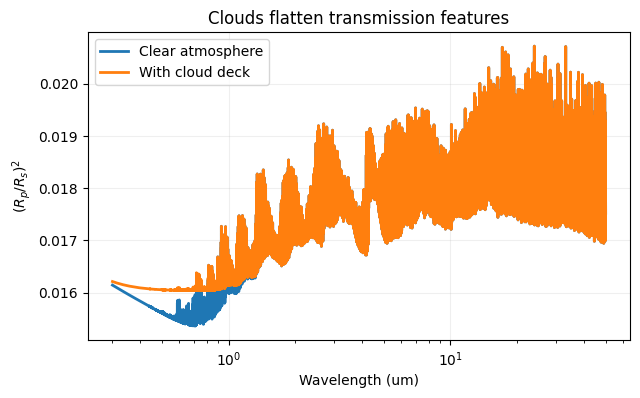

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(wlgrid, clear_rprs, label='Clear atmosphere', lw=2)
plt.plot(wlgrid, cloudy_rprs, label='With cloud deck', lw=2)
plt.xscale('log')
plt.xlabel('Wavelength (um)')
plt.ylabel('$(R_p/R_s)^2$')
plt.title('Clouds flatten transmission features')
plt.legend()
plt.grid(alpha=0.2)

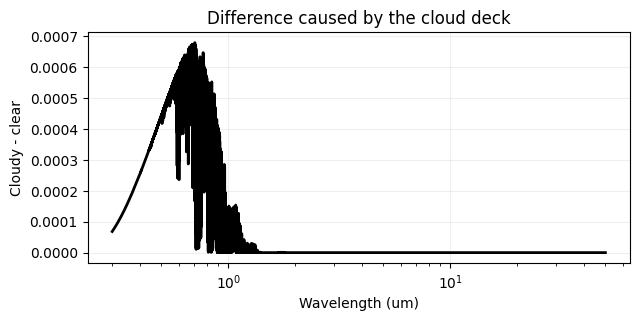

In [12]:
plt.figure(figsize=(7, 3))
plt.plot(wlgrid, difference, color='black', lw=2)
plt.xscale('log')
plt.xlabel('Wavelength (um)')
plt.ylabel('Cloudy - clear')
plt.title('Difference caused by the cloud deck')
plt.grid(alpha=0.2)

## Effect on Spectral Features

The cloud deck truncates the depth into the atmosphere that contributes to the spectrum. Molecular absorption features lose contrast because the effective path length through the gas is reduced. This same behaviour drives cloud–abundance degeneracies in atmospheric retrievals.

## FlatMie — Grey Cloud Layer

`FlatMieContribution` applies a flat opacity between a bottom and top pressure boundary. The `flat_mix_ratio` parameter controls the absorption strength: zero gives a clear atmosphere, while very large values mimic the infinite deck.

Setting `flat_bottomP=-1` extends the cloud to the bottom of the atmosphere.

In [ ]:
from taurex.contributions import FlatMieContribution

flatmie_context = build_transmission_model(
    include_cia=False,
    include_rayleigh=True,
    clouds=FlatMieContribution(flat_mix_ratio=1e-31, flat_bottomP=-1, flat_topP=1e3),
    download=False,
)
flatmie_tm = flatmie_context['tm']
_, flatmie_rprs, _, _ = flatmie_tm.model()
flatmie_rprs = flatmie_rprs[::-1]

plt.figure(figsize=(7, 4))
plt.plot(wlgrid, clear_rprs, lw=2, label='Clear')
plt.plot(wlgrid, flatmie_rprs, lw=2, label='FlatMie')
plt.xscale('log')
plt.xlabel('Wavelength (um)')
plt.ylabel('$(R_p/R_s)^2$')
plt.title('FlatMie cloud layer')
plt.legend()
plt.grid(alpha=0.2)

## LeeMie — Mie Scattering Approximation

`LeeMieContribution` computes wavelength-dependent scattering based on particle radius, extinction coefficient, and number density. Unlike the grey models above, LeeMie produces a wavelength-dependent cloud signature.

In [ ]:
from taurex.contributions import LeeMieContribution

leemie_context = build_transmission_model(
    include_cia=False,
    include_rayleigh=True,
    clouds=LeeMieContribution(
        lee_mie_radius=0.01,
        lee_mie_q=40,
        lee_mie_mix_ratio=1e14,
        lee_mie_topP=1e1,
        lee_mie_bottomP=-1,
    ),
    download=False,
)
leemie_tm = leemie_context['tm']
_, leemie_rprs, _, _ = leemie_tm.model()
leemie_rprs = leemie_rprs[::-1]

plt.figure(figsize=(7, 4))
plt.plot(wlgrid, clear_rprs, lw=2, label='Clear')
plt.plot(wlgrid, leemie_rprs, lw=2, label='LeeMie')
plt.xscale('log')
plt.xlabel('Wavelength (um)')
plt.ylabel('$(R_p/R_s)^2$')
plt.title('LeeMie cloud scattering')
plt.legend()
plt.grid(alpha=0.2)